# Modelo Original

## Librerías

In [5]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from minisom import MiniSom
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_digits
import pickle
from itertools import product
import pandas as pd
import plotly.graph_objects as go
import os
import time
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

## Modelo Original - Propuesto

In [ ]:
with open(r"C:\Users\kcarrascal\Downloads\Machine_Learning\X_sample.pkl", 'rb') as f:
    data = pickle.load(f)

Se implementó un modelo híbrido de aprendizaje no supervisado compuesto por un autoencoder profundo seguido de un algoritmo de agrupamiento basado en Self-Organizing Maps (SOM).

In [5]:
#parametros 
params = {
    # 'Encoding_Dim' : list(np.arange(2,int(data.shape[1]/2)+1)),
    'Encoding_Dim' : [2,5,10],
    'Layers' : [2, 4],
    'Neurons' : [64, 256],
    'Optimizer' : ["adam", "rmsprop"],
    'Epochs' : [100,500],
    'Sigma' : [0.1, 1],
    'LR' : [0.01, 0.1],
    
    'Activation' : ['relu'],
    'Loss' : ["mse"],
    'BS' : [64],
    'X' : [10],
    'Y' : [10],
    'Iterations' : [1000]

    }
params_idx={j:i for i,j in enumerate(params.keys())}

In [6]:

# Ruta para guardar resultados CSV
resultados_csv_path = r"C:\Users\Downloads\resultados_som.csv"

# Cargar backup si existe
try:
    with open(r"C:\Users\Downloads\Cluster.pkl", 'rb') as f:
        backup = pickle.load(f)
except:
    backup = {}

results = []
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

# Generar combinaciones
combinaciones = list(product(*params.values()))
total_iter = len(combinaciones)
start_total = time.time()

# Iterar con barra de progreso
with tqdm(total=total_iter, desc="Entrenando modelos") as pbar:
    for idx, i in enumerate(combinaciones):
        if i in backup:
            pbar.update(1)
            continue
        
        try:
            start_iter = time.time()
            print(f"\n▶ Iteración {idx+1}/{total_iter} - Configuración: {i}")

            # Dimensiones
            input_dim = data.shape[1]
            encoding_dim = i[params_idx['Encoding_Dim']]

            # Encoder
            enc_layers = [
                keras.layers.Dense(i[params_idx['Neurons']], activation=i[params_idx['Activation']], input_shape=(input_dim,))
                for _ in range(i[params_idx['Layers']])
            ]
            enc_layers.append(keras.layers.Dense(encoding_dim, activation='relu'))
            encoder = keras.Sequential(enc_layers)

            # Decoder
            dec_layers = [
                keras.layers.Dense(i[params_idx['Neurons']], activation=i[params_idx['Activation']], input_shape=(encoding_dim,))
                for _ in range(i[params_idx['Layers']])
            ]
            dec_layers.append(keras.layers.Dense(input_dim, activation='sigmoid'))
            decoder = keras.Sequential(dec_layers)

            # Autoencoder
            autoencoder = keras.Sequential([encoder, decoder])
            autoencoder.compile(optimizer=i[params_idx['Optimizer']], loss=i[params_idx['Loss']])
            autoencoder.fit(data_scaled, data_scaled, epochs=i[params_idx['Epochs']], batch_size=i[params_idx['BS']], verbose=0)

            # Codificación
            encoded_data = encoder.predict(data_scaled)

            # SOM
            som = MiniSom(i[params_idx['X']], i[params_idx['Y']], encoding_dim,
                          sigma=i[params_idx['Sigma']], learning_rate=i[params_idx['LR']])
            som.random_weights_init(encoded_data)
            som.train_random(encoded_data, i[params_idx['Iterations']])

            # Etiquetas
            som_labels = np.array([som.winner(x) for x in encoded_data])
            som_clusters = np.array([j[0] * i[params_idx['X']] + j[1] for j in som_labels])

            dummy= pd.DataFrame(som_clusters, columns=['Clus'])
            n_clus=len(dummy['Clus'].unique())
            dummy = dummy.groupby('Clus').agg({'Clus':'count'})
            dummy = (dummy/dummy.sum())['Clus'].values
            

            # Evaluación
            silhouette_combined = silhouette_score(encoded_data, som_clusters)
            davies_bouldin_combined = davies_bouldin_score(encoded_data, som_clusters)
            calinski_harabasz_combined = calinski_harabasz_score(encoded_data, som_clusters)

            # Guardar modelos .h5
            name = f"encdim{encoding_dim}_layers{i[params_idx['Layers']]}_neurons{i[params_idx['Neurons']]}"
            encoder.save(f"encoder_{name}.h5")
            autoencoder.save(f"autoencoder_{name}.h5")

            # Registro de resultados
            row = i + (silhouette_combined, davies_bouldin_combined, calinski_harabasz_combined) + (n_clus,dummy)
            backup[i] = row
            results.append(row)

            # Guardar backup .pkl
            with open(r"C:\Users\sherazoa\Downloads\Cluster.pkl", 'wb') as handle:
                pickle.dump(backup, handle, protocol=pickle.HIGHEST_PROTOCOL)

            # Guardar resultados parciales .csv
            columnas = list(params.keys()) + ['silhouette', 'davies_bouldin', 'calinski_harabasz'] + ['Clusters', 'Distribución']
            df_resultados = pd.DataFrame(results, columns=columnas)
            df_resultados.to_csv(resultados_csv_path, index=False)

            # Tiempo iteración
            elapsed = round(time.time() - start_iter, 2)
            print(f"⏱️ Iteración completada en {elapsed} segundos")

        except Exception as e:
            print(f"❌ Error en la configuración {i}: {e}")
        
        pbar.update(1)

# Tiempo total
total_time = round(time.time() - start_total, 2)
print(f"\n✅ Ejecución finalizada en {total_time} segundos")


C:\Users\sherazoa\AppData\Local\Temp\ipykernel_1700\4195772582.py:9: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  backup = pickle.load(f)
Entrenando modelos:   0%|          | 0/64 [00:00<?, ?it/s]


▶ Iteración 2/64 - Configuración: (5, 2, 64, 'adam', 100, 0.1, 0.1, 'relu', 'mse', 64, 10, 10, 1000)
4688/4688 ━━━━━━━━━━━━━━━━━━━━ 2s 370us/step


Entrenando modelos:   3%|▎         | 2/64 [07:20<3:47:29, 220.15s/it]

⏱️ Iteración completada en 440.3 segundos

▶ Iteración 3/64 - Configuración: (5, 2, 64, 'adam', 100, 1, 0.01, 'relu', 'mse', 64, 10, 10, 1000)
4688/4688 ━━━━━━━━━━━━━━━━━━━━ 2s 380us/step


Entrenando modelos:   5%|▍         | 3/64 [14:33<5:14:13, 309.08s/it]

...

⏱️ Iteración completada en 2641.26 segundos

▶ Iteración 63/64 - Configuración: (5, 4, 256, 'rmsprop', 500, 1, 0.01, 'relu', 'mse', 64, 10, 10, 1000)
4688/4688 ━━━━━━━━━━━━━━━━━━━━ 3s 527us/step


Entrenando modelos:  98%|█████████▊| 63/64 [19:37:45<35:10, 2110.20s/it]  

⏱️ Iteración completada en 2620.85 segundos

▶ Iteración 64/64 - Configuración: (5, 4, 256, 'rmsprop', 500, 1, 0.1, 'relu', 'mse', 64, 10, 10, 1000)
4688/4688 ━━━━━━━━━━━━━━━━━━━━ 2s 516us/step


Entrenando modelos: 100%|██████████| 64/64 [20:22:04<00:00, 1145.70s/it]

⏱️ Iteración completada en 2659.52 segundos

✅ Ejecución finalizada en 73324.59 segundos


## Clusters

In [1]:
# Cargar archivo CSV
ruta_csv = r"C:\Users\kelly\Downloads\Machine_Learning\Modelo_Original\resultados_som.csv"  
df = pd.read_csv(ruta_csv)

# Mejor modelo según cada métrica
mejor_silhouette = df.loc[df['silhouette'].idxmax()]
mejor_davies = df.loc[df['davies_bouldin'].idxmin()]
mejor_calinski = df.loc[df['calinski_harabasz'].idxmax()]

# Mostrar resultados
print("🔹 Mejor modelo según Silhouette Score:")
print(mejor_silhouette, "\n")

print("🔹 Mejor modelo según Davies-Bouldin Score:")
print(mejor_davies, "\n")

print("🔹 Mejor modelo según Calinski-Harabasz Score:")
print(mejor_calinski, "\n")


🔹 Mejor modelo según Silhouette Score:
Encoding_Dim                  5
Layers                        4
Neurons                     256
Activation                 adam
Optimizer                   100
Loss                        1.0
Epochs                      0.1
BS                         relu
X                           mse
Y                            64
Sigma                      10.0
LR                         10.0
Iterations                 1000
silhouette             0.526466
davies_bouldin         0.670487
calinski_harabasz    39204074.0
Name: 75, dtype: object 

🔹 Mejor modelo según Davies-Bouldin Score:
Encoding_Dim                5
Layers                      4
Neurons                   256
Activation               adam
Optimizer                 100
Loss                      1.0
Epochs                   0.01
BS                       relu
X                         mse
Y                          64
Sigma                    10.0
LR                       10.0
Iterations          

In [9]:
# Cargar datos y escalar
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)  

# Parámetros del mejor modelo (según Silhouette, por ejemplo)
params_silhouette = {
    "Encoding_Dim": 5,
    "Layers": 4,
    "Neurons": 256,
    "Activation": 'relu',
    "X": 10,
    "Y": 10,
    "Sigma": 0.1,
    "LR": 0.01,
    "Iterations": 1000
}

## Silhouette

In [11]:
# Hiperparámetros del mejor modelo
encoding_dim = 5
n_layers = 4
neurons = 256
activation = 'relu'
epochs = 100  
batch_size = 64
input_dim = data.shape[1]

# =======================
# Construir Encoder
# =======================
enc_layers = [keras.layers.Dense(neurons, activation=activation, input_shape=(input_dim,))]
for _ in range(n_layers - 1):
    enc_layers.append(keras.layers.Dense(neurons, activation=activation))
enc_layers.append(keras.layers.Dense(encoding_dim, activation='relu'))
encoder = keras.Sequential(enc_layers)

# =======================
# Construir Decoder
# =======================
dec_layers = [keras.layers.Dense(neurons, activation=activation, input_shape=(encoding_dim,))]
for _ in range(n_layers - 1):
    dec_layers.append(keras.layers.Dense(neurons, activation=activation))
dec_layers.append(keras.layers.Dense(input_dim, activation='sigmoid'))
decoder = keras.Sequential(dec_layers)

# =======================
# Autoencoder
# =======================
autoencoder = keras.Sequential([encoder, decoder])
autoencoder.compile(optimizer="adam", loss="mse")
autoencoder.fit(data_scaled, data_scaled, epochs=epochs, batch_size=batch_size, verbose=0)

# =======================
# Obtener Embeddings
# =======================
X_embedded = encoder.predict(data_scaled)

# =======================
# Aplicar SOM
# =======================
som = MiniSom(10, 10, encoding_dim, sigma=0.1, learning_rate=0.01)
som.random_weights_init(X_embedded)
som.train_random(X_embedded, 1000)

som_labels = np.array([som.winner(x) for x in X_embedded])
som_clusters = np.array([j[0]*10 + j[1] for j in som_labels])

# Asignar al DataFrame
df_resultado = pd.DataFrame(data)
df_resultado["cluster_silhouette"] = som_clusters


C:\Users\keine\anaconda3\envs\dec_env\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4688/4688 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step


In [13]:
df_resultado

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,cluster_silhouette
0,0.397969,-0.463200,-0.221665,-0.223972,-0.907863,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,3
1,-0.405570,-0.463200,-0.221665,0.026813,0.005213,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,22
2,-0.599528,0.353273,-0.221665,-0.199454,-0.828808,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,52
3,-0.546882,-0.463200,-0.221665,-0.153921,-0.610619,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,68
4,-0.521945,3.619164,-0.221665,-0.161393,-0.515754,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,-0.599528,0.353273,-0.221665,-0.156256,-0.670700,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,52
149996,-0.516403,-0.463200,-0.221665,-0.181941,-0.658842,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,60
149997,1.453654,-0.463200,-0.221665,0.087057,1.108018,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,48
149998,-0.599528,-0.463200,-0.221665,-0.147616,-0.710227,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,90


In [17]:
df_resultado.to_csv("df_resultado_SIL.csv", index=False)
print("ok")

ok


## Davies-Bouldin

In [6]:


# Hiperparámetros del mejor modelo
encoding_dim = 5
n_layers = 4
neurons = 256
activation = 'relu'
epochs = 100  
batch_size = 64
input_dim = data.shape[1]

# =======================
# Construir Encoder
# =======================
enc_layers = [keras.layers.Dense(neurons, activation=activation, input_shape=(input_dim,))]
for _ in range(n_layers - 1):
    enc_layers.append(keras.layers.Dense(neurons, activation=activation))
enc_layers.append(keras.layers.Dense(encoding_dim, activation='relu'))
encoder = keras.Sequential(enc_layers)

# =======================
# Construir Decoder
# =======================
dec_layers = [keras.layers.Dense(neurons, activation=activation, input_shape=(encoding_dim,))]
for _ in range(n_layers - 1):
    dec_layers.append(keras.layers.Dense(neurons, activation=activation))
dec_layers.append(keras.layers.Dense(input_dim, activation='sigmoid'))
decoder = keras.Sequential(dec_layers)

# =======================
# Autoencoder
# =======================
autoencoder = keras.Sequential([encoder, decoder])
autoencoder.compile(optimizer="adam", loss="mse")
autoencoder.fit(data_scaled, data_scaled, epochs=epochs, batch_size=batch_size, verbose=0)

# =======================
# Obtener Embeddings
# =======================
X_embedded = encoder.predict(data_scaled)

# =======================
# Aplicar SOM
# =======================
som = MiniSom(10, 10, encoding_dim, sigma=0.1, learning_rate=0.01)
som.random_weights_init(X_embedded)
som.train_random(X_embedded, 1000)

som_labels = np.array([som.winner(x) for x in X_embedded])
som_clusters = np.array([j[0]*10 + j[1] for j in som_labels])

# Asignar al DataFrame
df_resultado = pd.DataFrame(data)
df_resultado["cluster_db"] = som_clusters
print("cluster_db ok")

C:\Users\kcarrascal\AppData\Local\anaconda3\envs\sklearn_env\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4688/4688 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step
cluster_db ok


In [7]:
df_resultado

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,cluster_db
0,0.397969,-0.463200,-0.221665,-0.223972,-0.907863,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,92
1,-0.405570,-0.463200,-0.221665,0.026813,0.005213,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,60
2,-0.599528,0.353273,-0.221665,-0.199454,-0.828808,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,78
3,-0.546882,-0.463200,-0.221665,-0.153921,-0.610619,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,65
4,-0.521945,3.619164,-0.221665,-0.161393,-0.515754,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,-0.599528,0.353273,-0.221665,-0.156256,-0.670700,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,9
149996,-0.516403,-0.463200,-0.221665,-0.181941,-0.658842,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,82
149997,1.453654,-0.463200,-0.221665,0.087057,1.108018,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,67
149998,-0.599528,-0.463200,-0.221665,-0.147616,-0.710227,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,47


In [8]:
df_resultado.to_csv("df_resultado_db.csv", index=False)
print("ok")

ok


## Calinski-Harabasz

In [2]:

scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

# Hiperparámetros del mejor modelo
encoding_dim = 10
n_layers = 2
neurons = 64
activation = 'relu'
epochs = 100  
batch_size = 64
input_dim = data.shape[1]

# =======================
# Construir Encoder
# =======================
enc_layers = [keras.layers.Dense(neurons, activation=activation, input_shape=(input_dim,))]
for _ in range(n_layers - 1):
    enc_layers.append(keras.layers.Dense(neurons, activation=activation))
enc_layers.append(keras.layers.Dense(encoding_dim, activation='relu'))
encoder = keras.Sequential(enc_layers)

# =======================
# Construir Decoder
# =======================
dec_layers = [keras.layers.Dense(neurons, activation=activation, input_shape=(encoding_dim,))]
for _ in range(n_layers - 1):
    dec_layers.append(keras.layers.Dense(neurons, activation=activation))
dec_layers.append(keras.layers.Dense(input_dim, activation='sigmoid'))
decoder = keras.Sequential(dec_layers)

# =======================
# Autoencoder
# =======================
autoencoder = keras.Sequential([encoder, decoder])
autoencoder.compile(optimizer="adam", loss="mse")
autoencoder.fit(data_scaled, data_scaled, epochs=epochs, batch_size=batch_size, verbose=0)

# =======================
# Obtener Embeddings
# =======================
X_embedded = encoder.predict(data_scaled)

# =======================
# Aplicar SOM
# =======================
som = MiniSom(10, 10, encoding_dim, sigma=0.1, learning_rate=0.01)
som.random_weights_init(X_embedded)
som.train_random(X_embedded, 1000)

som_labels = np.array([som.winner(x) for x in X_embedded])
som_clusters = np.array([j[0]*10 + j[1] for j in som_labels])

# Asignar al DataFrame
df_resultado = pd.DataFrame(data)
df_resultado["cluster_ch"] = som_clusters
print("cluster_ch ok")

C:\Users\kcarrascal\AppData\Local\anaconda3\envs\sklearn_env\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4688/4688 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step
cluster_ch ok


In [3]:
df_resultado

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,cluster_ch
0,0.397969,-0.463200,-0.221665,-0.223972,-0.907863,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,55
1,-0.405570,-0.463200,-0.221665,0.026813,0.005213,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,87
2,-0.599528,0.353273,-0.221665,-0.199454,-0.828808,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,73
3,-0.546882,-0.463200,-0.221665,-0.153921,-0.610619,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,13
4,-0.521945,3.619164,-0.221665,-0.161393,-0.515754,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,-0.599528,0.353273,-0.221665,-0.156256,-0.670700,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,73
149996,-0.516403,-0.463200,-0.221665,-0.181941,-0.658842,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,61
149997,1.453654,-0.463200,-0.221665,0.087057,1.108018,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,49
149998,-0.599528,-0.463200,-0.221665,-0.147616,-0.710227,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,47


In [4]:
df_resultado.to_csv("df_resultado_ch.csv", index=False)
print("ok")

ok


## Visualización cluster

In [6]:
# Cargar cada DataFrame
df_sil = pd.read_csv(r"C:\Users\kcarrascal\Downloads\df_resultado_SIL.csv")
df_db = pd.read_csv(r"C:\Users\kcarrascal\Downloads\df_resultado_db.csv")
df_ch = pd.read_csv(r"C:\Users\kcarrascal\Downloads\df_resultado_ch.csv")

In [7]:
df_sil

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,cluster_silhouette
0,0.397969,-0.463200,-0.221665,-0.223972,-0.907863,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,3
1,-0.405570,-0.463200,-0.221665,0.026813,0.005213,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,22
2,-0.599528,0.353273,-0.221665,-0.199454,-0.828808,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,52
3,-0.546882,-0.463200,-0.221665,-0.153921,-0.610619,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,68
4,-0.521945,3.619164,-0.221665,-0.161393,-0.515754,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,-0.599528,0.353273,-0.221665,-0.156256,-0.670700,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,52
149996,-0.516403,-0.463200,-0.221665,-0.181941,-0.658842,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,60
149997,1.453654,-0.463200,-0.221665,0.087057,1.108018,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,48
149998,-0.599528,-0.463200,-0.221665,-0.147616,-0.710227,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,90


In [ ]:
# Asegurarse que las columnas de features 
features_columns_sil = [col for col in df_sil.columns if col not in ['cluster_silhouette']]
features_columns_db = [col for col in df_db.columns if col not in ['cluster_db']]
features_columns_ch = [col for col in df_ch.columns if col not in ['cluster_ch']]

In [9]:
# Función para graficar PCA ocultando la leyenda
def visualizar_pca(df, cluster_col, features_cols, title):
    X = df[features_cols]
    y = df[cluster_col]
    
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    
    df_plot = pd.DataFrame({
        'PCA1': X_pca[:, 0],
        'PCA2': X_pca[:, 1],
        'Cluster': y
    })
    
    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        data=df_plot,
        x='PCA1',
        y='PCA2',
        hue='Cluster',
        palette='tab10',
        s=50,
        alpha=0.7,
        legend=False  # <<<<<< Aquí está el cambio importante
    )
    plt.title(f"Visualización PCA - {title}")
    plt.tight_layout()
    plt.show()


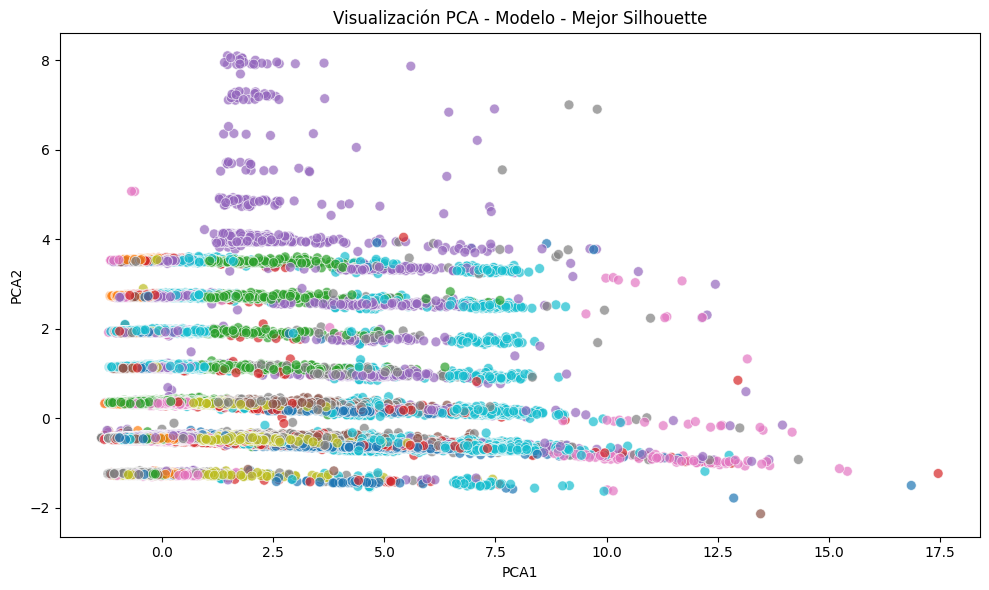

In [13]:
# Visualizar para cada métrica
visualizar_pca(df_sil, 'cluster_silhouette', features_columns_sil, "Modelo - Mejor Silhouette")


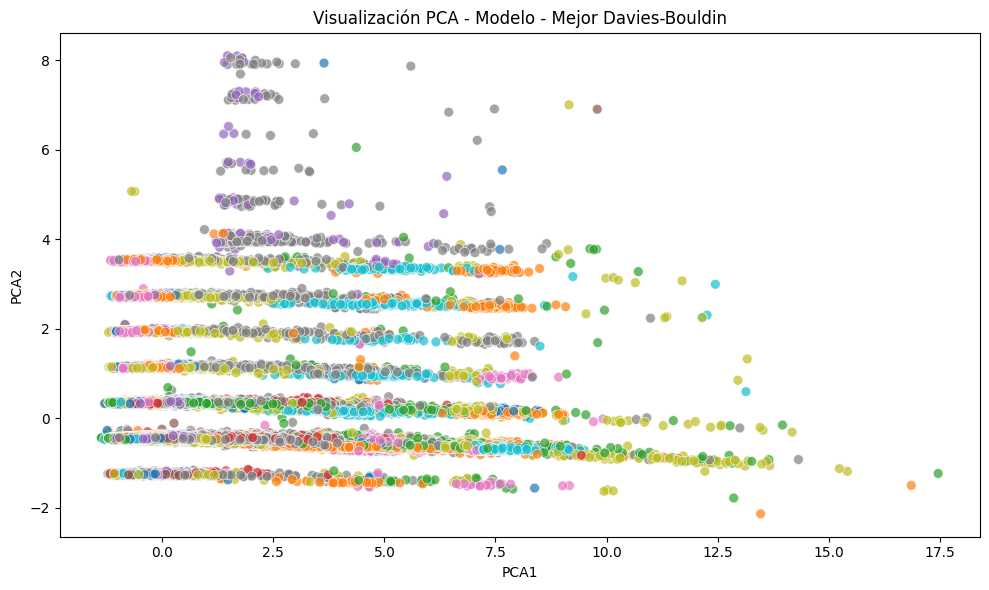

In [14]:
# Visualizar para cada métrica
visualizar_pca(df_db, 'cluster_db', features_columns_db, "Modelo - Mejor Davies-Bouldin")


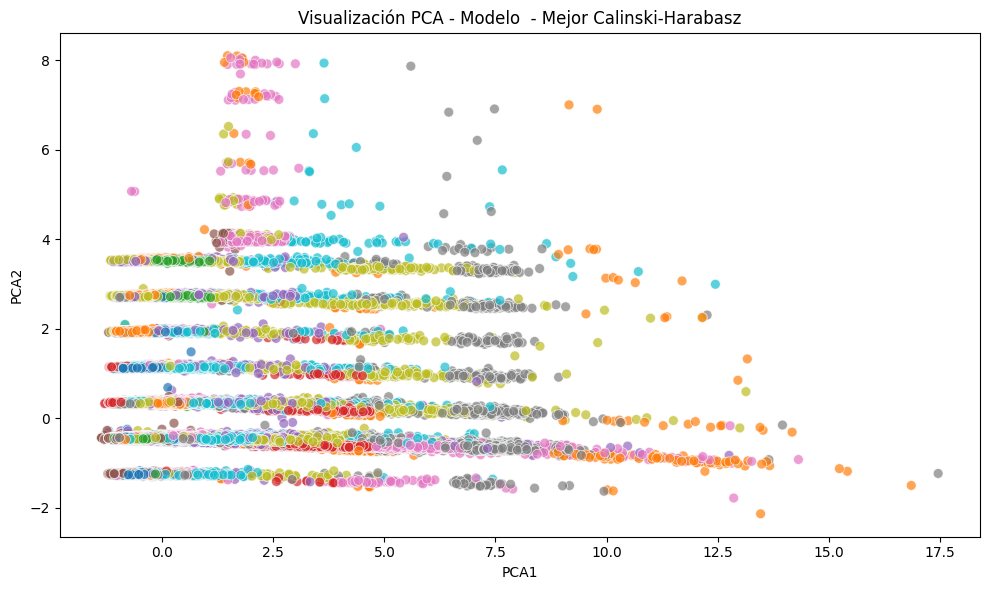

In [15]:
# Visualizar para cada métrica
visualizar_pca(df_ch, 'cluster_ch', features_columns_ch, "Modelo  - Mejor Calinski-Harabasz")


In [16]:
def mostrar_proporciones(df, cluster_col, nombre_metrica):
    conteo = df[cluster_col].value_counts(normalize=True).sort_values(ascending=False)
    print(f"🔹 Proporciones de clústeres para {nombre_metrica}:\n")
    print(conteo)
    print("\n")


In [18]:
mostrar_proporciones(df_sil, 'cluster_silhouette', "Silhouette")
mostrar_proporciones(df_db, 'cluster_db', "Davies-Bouldin")
mostrar_proporciones(df_ch, 'cluster_ch', "Calinski-Harabasz")

🔹 Proporciones de clústeres para Silhouette:

cluster_silhouette
37    0.051567
52    0.039873
48    0.038247
44    0.035447
10    0.030653
        ...   
26    0.001313
93    0.001047
12    0.000693
50    0.000527
82    0.000327
Name: proportion, Length: 100, dtype: float64


🔹 Proporciones de clústeres para Davies-Bouldin:

cluster_db
6     0.041020
25    0.033800
54    0.032480
60    0.026913
11    0.025807
        ...   
63    0.001660
75    0.001127
77    0.001080
2     0.000907
76    0.000660
Name: proportion, Length: 100, dtype: float64


🔹 Proporciones de clústeres para Calinski-Harabasz:

cluster_ch
2     0.035213
49    0.028687
78    0.026940
62    0.025827
27    0.024927
        ...   
85    0.001867
36    0.001633
94    0.001447
76    0.001280
26    0.001100
Name: proportion, Length: 100, dtype: float64




In [21]:

# Proporciones por métrica TOP 10
silhouette_props = {
    37: 0.051567, 52: 0.039873, 48: 0.038247, 44: 0.035447, 10: 0.030653,
    26: 0.001313, 93: 0.001047, 12: 0.000693, 50: 0.000527, 82: 0.000327
}

db_props = {
    6: 0.041020, 25: 0.033800, 54: 0.032480, 60: 0.026913, 11: 0.025807,
    63: 0.001660, 75: 0.001127, 77: 0.001080, 2: 0.000907, 76: 0.000660
}

ch_props = {
    2: 0.035213, 49: 0.028687, 78: 0.026940, 62: 0.025827, 27: 0.024927,
    85: 0.001867, 36: 0.001633, 94: 0.001447, 76: 0.001280, 26: 0.001100
}

# Crear DataFrame
df_props = pd.DataFrame({
    'Cluster_Silhouette': pd.Series(silhouette_props),
    'Cluster_DB': pd.Series(db_props),
    'Cluster_CH': pd.Series(ch_props)
}).fillna(0)

# Calcular suma de proporciones de los top-5 más representativos
top_sil = df_props['Cluster_Silhouette'].sort_values(ascending=False).head(5).sum()
top_db = df_props['Cluster_DB'].sort_values(ascending=False).head(5).sum()
top_ch = df_props['Cluster_CH'].sort_values(ascending=False).head(5).sum()

# Tabla resumen
summary = pd.DataFrame({
    'Métrica': ['Silhouette', 'Davies-Bouldin', 'Calinski-Harabasz'],
    'Top-5 Proporción Acumulada': [top_sil, top_db, top_ch]
})


# Determinar mejor métrica (mayor concentración en top-5)
mejor_met = summary.sort_values(by='Top-5 Proporción Acumulada', ascending=False).iloc[0]
mejor_met


Métrica                       Silhouette
Top-5 Proporción Acumulada      0.195787
Name: 0, dtype: object

La métrica Silhouette logra la mayor concentración de datos en sus 5 clústeres principales, lo cual sugiere una mejor cohesión de grupos y distribución más interpretable. Por tanto, Silhouette se considera la mejor métrica para este modelo.

In [28]:

# dataset original 
df_original = pd.read_csv(r"C:\Users\kcarrascal\Downloads\Machine_Learning\df_clustering.csv")  

# muestra de 150,000 registros
df_sample_original = resample(df_original, n_samples=150000, random_state=42)

# df_sample_original 
print(df_sample_original.shape)
print(df_sample_original.head())


(150000, 7)
         total_amount  Distance  Passengers  tolls_amount  Duration_seconds  \
6413414          3.80      4.20         1.0           0.0              25.0   
6962611         15.35      1.30         1.0           0.0            1099.0   
6423388          4.80      0.60         2.0           0.0             130.0   
6550634          7.56      0.79         1.0           0.0             325.0   
1692743          8.76      0.88         6.0           0.0             293.0   

         payment_type  RatecodeID  
6413414             3         1.0  
6962611             1         1.0  
6423388             2         1.0  
6550634             1         1.0  
1692743             1         1.0  


In [29]:
labels_clusters = df_sil["cluster_silhouette"].values

In [32]:
# Asignar los clústeres a la muestra 
df_sample_original['cluster_silhouette'] = labels_clusters  
df_sample_original

,total_amount,Distance,Passengers,tolls_amount,Duration_seconds,payment_type,RatecodeID,cluster_silhouette
6413414,3.80,4.20,1.0,0.00,25.0,3,1.0,3
6962611,15.35,1.30,1.0,0.00,1099.0,1,1.0,22
6423388,4.80,0.60,2.0,0.00,130.0,2,1.0,52
6550634,7.56,0.79,1.0,0.00,325.0,1,1.0,68
1692743,8.76,0.88,6.0,0.00,293.0,1,1.0,17
...,...,...,...,...,...,...,...,...
1460769,6.80,0.60,2.0,0.00,315.0,2,1.0,52
1243330,6.95,0.90,1.0,0.00,205.0,1,1.0,60
4941389,29.30,8.01,1.0,0.00,1357.0,1,1.0,48
3901676,6.30,0.60,1.0,0.00,352.0,2,1.0,90


In [34]:
df_sample_original.groupby('cluster_silhouette').mean()

,total_amount,Distance,Passengers,tolls_amount,Duration_seconds,payment_type,RatecodeID
cluster_silhouette,,,,,,,
0,13.689727,1.760449,4.463884,0.000000,799.112360,1.000000,1.000000
1,7.658546,0.603991,2.000000,0.000000,311.577882,1.000000,1.000000
2,13.453507,1.802958,0.992958,0.000000,777.243662,1.000000,1.000000
3,22.111068,3.775239,2.784761,0.486104,968.058975,1.931985,2.271632
4,20.797892,4.942260,0.993274,0.012915,1381.962332,2.000000,1.000000
...,...,...,...,...,...,...,...
95,8.829137,1.476735,1.000000,0.000000,494.417582,2.000000,1.000000
96,8.334262,0.625831,1.000000,0.000000,378.759115,1.000000,1.000000
97,12.920533,2.509614,0.972426,0.000000,618.044118,1.000000,1.000000


## Mejor modelo base: Agglomerative

In [36]:
clusters_agglomerative = pd.read_csv(r"C:\Users\kcarrascal\Downloads\Machine_Learning\clusters_agglomerative_sample.csv")  
clusters_agglomerative

,cluster_silhouette,cluster_calinski_harabasz,cluster_davies_bouldin
0,0,0,0
1,0,0,0
2,0,0,0
3,0,0,0
4,0,0,0
...,...,...,...
149995,0,0,0
149996,0,0,0
149997,0,0,0
149998,0,0,0


In [37]:
labels_clusters_aggl = clusters_agglomerative["cluster_silhouette"].values

In [38]:
# Asignar los clústeres a la muestra 
df_sample_original['cluster_silhouette_Aggl'] = labels_clusters_aggl  
df_sample_original

,total_amount,Distance,Passengers,tolls_amount,Duration_seconds,payment_type,RatecodeID,cluster_silhouette,cluster_silhouette_Aggl
6413414,3.80,4.20,1.0,0.00,25.0,3,1.0,3,0
6962611,15.35,1.30,1.0,0.00,1099.0,1,1.0,22,0
6423388,4.80,0.60,2.0,0.00,130.0,2,1.0,52,0
6550634,7.56,0.79,1.0,0.00,325.0,1,1.0,68,0
1692743,8.76,0.88,6.0,0.00,293.0,1,1.0,17,0
...,...,...,...,...,...,...,...,...,...
1460769,6.80,0.60,2.0,0.00,315.0,2,1.0,52,0
1243330,6.95,0.90,1.0,0.00,205.0,1,1.0,60,0
4941389,29.30,8.01,1.0,0.00,1357.0,1,1.0,48,0
3901676,6.30,0.60,1.0,0.00,352.0,2,1.0,90,0


In [39]:
df_sample_original.groupby('cluster_silhouette_Aggl').mean()

,total_amount,Distance,Passengers,tolls_amount,Duration_seconds,payment_type,RatecodeID,cluster_silhouette
cluster_silhouette_Aggl,,,,,,,,
0,15.282279,2.753531,1.568478,0.293061,979.210624,1.292146,1.047814,47.379868
1,88.300000,18.650000,1.000000,15.500000,35519.000000,2.000000,3.000000,3.000000
2,46.170000,0.450000,0.500000,36.380000,473.000000,1.000000,1.000000,52.500000
